#  scikit-learn中的主成分分析 - 实验

## 引言
既然你已经对主成分分析有了一个简要的了解，那么现在是时候使用scikit-learn自己来运行主成分分析了。

## 目标
在本实验中，你将：
- 使用scikit-learn库实现主成分分析
- 通过观察解释方差来确定执行主成分分析时的最优成分数量n
- 绘制分类实验的决策边界，以便直观检查其性能

## 鸢尾花数据集
为了练习主成分分析（PCA），你将了解鸢尾花数据集。   

iris鸾尾花数据集有4个特征：萼片长度、萼片宽度、花瓣长度、花瓣宽度。还有一个种类y（3个：山鸾尾、变色鸾尾、维吉尼亚鸾尾）

运行下面的代码块来加载它。 

In [1]:
from sklearn import datasets
import pandas as pd
 
iris = datasets.load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['Target'] = iris.get('target')
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


在执行主成分分析（PCA）并可视化主成分之前，多了解一些你要处理的数据背景会很有帮助。运行下面的代码块以可视化成对特征图。通过这个图，注意目标标签如何能通过任何一个给定特征轻松区分开来。

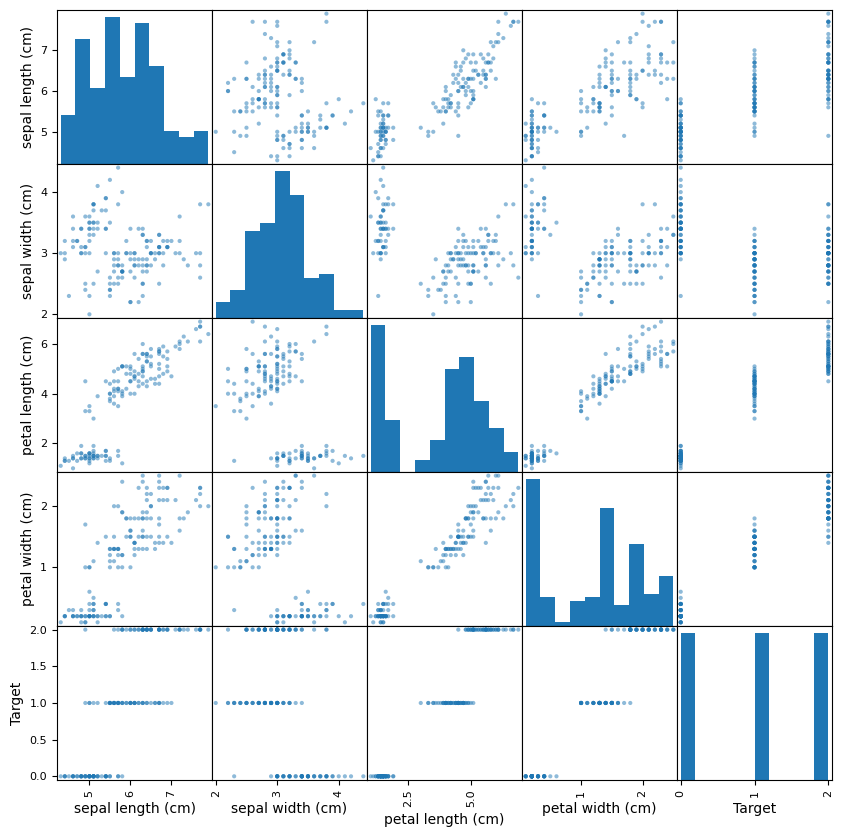

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

pd.plotting.scatter_matrix(df, figsize=(10,10));
plt.show()

- 将以下`features`列表中的所有列赋值给`X` 
- 将`'Target'`列赋值给`y`

In [3]:
# 创建特征和目标数据集
features = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
X = df[features]
y = df['Target']

使用`StandardScaler`对`X`中的所有列进行标准化。

In [4]:
# 导入StandardScaler
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Preview X
pd.DataFrame(data=X_scaled, columns=features).head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


## 主成分分析（PCA）投影到二维空间
现在是时候进行主成分分析（PCA）了！将原本4维的数据投影到2维空间。新的成分正是数据中存在的两个主要的方差维度。
- 从scikit-learn库中初始化一个具有两个成分的PCA实例
- 将数据拟合到模型
- 从训练好的模型中提取前两个主成分

In [5]:
# Import PCA
from sklearn.decomposition import PCA

# Instantiate PCA
pca = PCA(n_components=2)

# Fit PCA
principalComponents = pca.fit_transform(X_scaled)

为了直观地展示这些成分，查看与特定观测值相关联的目标也将很有用。 
因此，将目标（花卉类型）添加到pandas数据框中的主成分里。

In [6]:
# Create a new dataset from principal components 
principal_df = pd.DataFrame(data=principalComponents, columns=['PC1', 'PC2'])

# Appending the target column
principal_df['Target'] = y
principal_df.head()

,PC1,PC2,Target
0,-2.264703,0.480027,0
1,-2.080961,-0.674134,0
2,-2.364229,-0.341908,0
3,-2.299384,-0.597395,0
4,-2.389842,0.646835,0


很好，现在你有了一组二维数据，相对于我们的目标变量（花卉类型），从四维数据精简而来。

## 可视化主成分
利用目标数据，我们可以根据类别分布来可视化主成分。
- 根据每个样本被分类的花卉类型对样本进行颜色编码，同时从主成分创建散点图

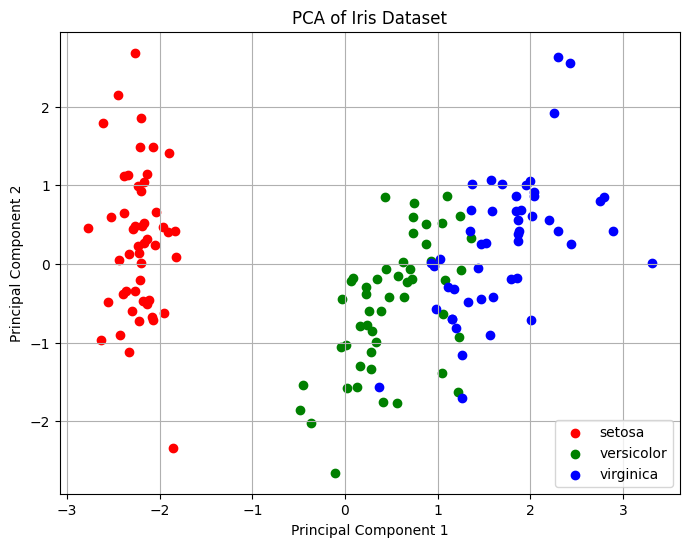

In [7]:
# Principal Components scatter plot
# Defining target names
target_names = iris.target_names
colors = ['r', 'g', 'b']

# Your code here 
plt.figure(figsize=(8, 6))
for target, color in zip([0, 1, 2], colors):
    subset = principal_df[principal_df['Target'] == target]
    plt.scatter(subset['PC1'], subset['PC2'], label=target_names[target], color=color)

plt.title('PCA of Iris Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

## 解释方差
如你在上面所见，数据集中的三个类别相当容易区分。因此，这种数据的压缩表示可能足以满足当前的分类任务。将整个数据集的方差与从两个主成分中获取的方差进行比较。

In [8]:
# 计算主成分解释的方差
print('Variance of each component:', pca.explained_variance_ratio_)
print('\nTotal Variance Explained:', sum(pca.explained_variance_ratio_))

Variance of each component: [0.72962445 0.22850762]

Total Variance Explained: 0.9581320720000165


如你所见，前两个主成分占了数据集中总体方差的绝大部分。

## 比较使用主成分分析（PCA）的分类器性能
由于主成分解释了数据中95%的方差，因此考虑在压缩版本上训练的分类器与在原始数据集上训练的分类器相比表现如何是很有趣的。
- 运行`KNeighborsClassifier`对鸢尾花数据集进行分类
- 使用80/20的训练集/测试集划分
- 为了结果的可重复性，在划分时设置`random_state=9`
- 记录划分、训练和进行预测的过程所花费的时间

In [9]:
# 分类 - 完整鸢尾花数据集
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import time

# Your code here 
# Splitting original standardized data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=9)

# Start timer
start_time = time.time()

# Training the classifier
knn_full = KNeighborsClassifier()
knn_full.fit(X_train, y_train)

# Prediction
y_pred_full = knn_full.predict(X_test)

# End timer
end_time = time.time()

# Accuracy
accuracy_full = accuracy_score(y_test, y_pred_full)

print("Full Dataset Classification Accuracy:", accuracy_full)
print("Time Taken:", round(end_time - start_time, 4), "seconds")

Full Dataset Classification Accuracy: 1.0
Time Taken: 0.0012 seconds


很好，所以你可以看到我们能够在给定时间内以100%的准确率对数据进行分类。请记住，根据你CPU的负载以及你机器上运行的进程数量，所花费的时间可能会有所不同。

现在，对由主成分构成的数据集重复上述过程：
- 运行`KNeighborsClassifier`，使用主成分对鸢尾花数据集进行分类
- 使用80/20的训练集/测试集划分比例
- 为确保结果的可重复性，将划分的`random_state`设置为9
- 记录划分、训练和进行预测过程所花费的时间

In [10]:
# 分类 - 降维（PCA）鸢尾花数据集

# Splitting PCA-reduced data
X_pca = principal_df[['PC1', 'PC2']].values
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=9)

# Start timer
start_time = time.time()

# Training the classifier
knn_pca = KNeighborsClassifier()
knn_pca.fit(X_train_pca, y_train_pca)

# Predictions
y_pred_pca = knn_pca.predict(X_test_pca)

# End timer
end_time = time.time()

# Accuracy
accuracy_pca = accuracy_score(y_test_pca, y_pred_pca)

print("PCA Dataset Classification Accuracy:", accuracy_pca)
print("Time Taken:", round(end_time - start_time, 4), "seconds")

PCA Dataset Classification Accuracy: 0.9666666666666667
Time Taken: 0.0025 seconds


虽然这种数据表示方式会损失一些准确性，但我们能够使用一半数量的特征来训练模型！   

在更复杂的情况下，主成分分析（PCA）甚至可以提高某些机器学习任务的准确性。特别是，PCA对于减少过拟合可能很有用。

## 可视化学习到的决策边界
运行下面的代码块，以可视化使用数据主成分训练的k近邻分类模型所学习到的决策边界。 

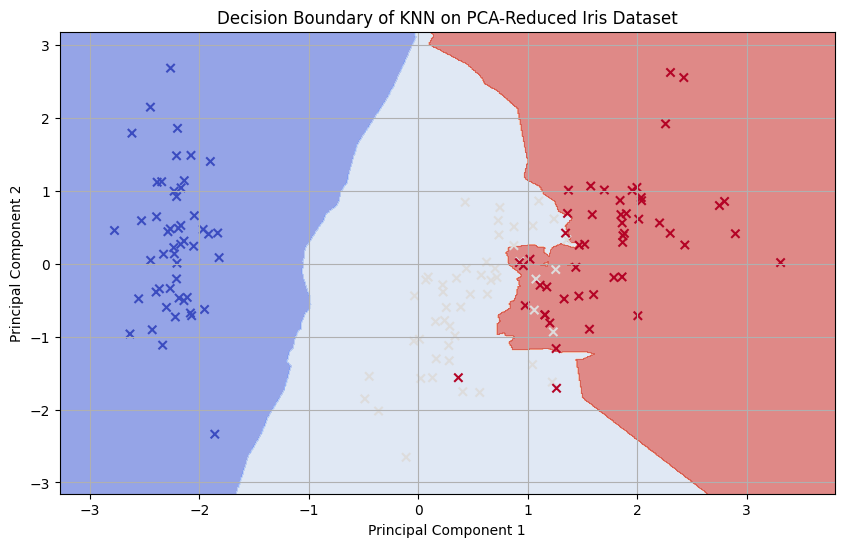

In [11]:
# Plot decision boundary using principal components 
import numpy as np 

# X for PCA-reduced dataframe
X_pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

def decision_boundary(pred_func):
    # Set the boundary using PCA components
    x_min, x_max = X_pca_df.iloc[:, 0].min() - 0.5, X_pca_df.iloc[:, 0].max() + 0.5
    y_min, y_max = X_pca_df.iloc[:, 1].min() - 0.5, X_pca_df.iloc[:, 1].max() + 0.5
    h = 0.01

    # Build meshgrid
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Predict over meshgrid
    Z = pred_func(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the contour and the points
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.6)
    plt.scatter(X_pca_df["PC1"], X_pca_df["PC2"], c=y, cmap=plt.cm.coolwarm, marker='x')
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title("Decision Boundary of KNN on PCA-Reduced Iris Dataset")
    plt.grid(True)
    plt.show()

# Use knn_pca for prediction
decision_boundary(lambda x: knn_pca.predict(x))

## 总结
在本实验中，你将主成分分析（PCA）应用于广为人知的鸢尾花数据集。你研究了一个简单分类器的性能，以及PCA对模型准确性和模型运行时间的影响。从这里开始，你将继续在更基础的层面上探索PCA。 